In [3]:
import numpy as np
from numpy import ndarray
from typing import Callable, Dict, Tuple, List

In [4]:
np.set_printoptions(precision=4)
TEST_ALL = False

Data Importation and Loading

In [5]:
'''
from sklearn.datasets import load_boston
boston = load_boston
data = boston.data
target = boston.target
features = boston.feature_names
'''
# Boston housing data has been deprecated because of ethical issues, but I am using it for learning purpose only
import pandas as pd
pd.set_option('display.width', 1000)

features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Data visualization using DF
'''
df = pd.DataFrame(data, columns=features)
df['TARGET'] = target
print(df.head())
'''


"\ndf = pd.DataFrame(data, columns=features)\ndf['TARGET'] = target\nprint(df.head())\n"

Data Prep

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
s = StandardScaler()
data = s.fit_transform(data)
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=80718)
y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)

In [7]:
def mse(actual: ndarray, prediction: ndarray):
  # Mean Squared Error Computation
  return np.mean(np.square(actual-prediction))

def mae(actual: ndarray, prediction: ndarray):
  # Mean Absolute Error Computation
  return np.mean(np.abs(actual-prediction))

def rmse(actual: ndarray, prediction: ndarray):
  # Root Mean Square Error
  return np.sqrt(mse(actual, prediction))

In [8]:
def forward_pass(x_batch: ndarray,
                 y_batch: ndarray,
                 weights: Dict[str, ndarray]
                 ) -> Tuple[float, Dict[str, ndarray]]:

    # Forward pass algorithm for the step-by-step linear regression model

    w_batch: ndarray = weights['W']
    b_batch: ndarray = weights['B']

    # Assert that batch sizes of X and Y matrices are equal.
    # This is to ensure that all observations for training have targets.
    # That there are no missing targets.
    assert x_batch.shape[0] == y_batch.shape[0]

    #Assert that matrice multiplication can work. i.e n of x_batch == m of weights['W']
    assert x_batch.shape[1] == w_batch.shape[0]

    # Assert that B, the intersection on the dependent axis is a 1x1 array
    assert b_batch.shape[0] == b_batch.shape[1]

    # Compute the operations on the forward pass
    n: ndarray = np.dot(x_batch, w_batch)
    p: ndarray = n + b_batch

    # Finding the residuals - the loss
    loss: float = np.mean(np.square(y_batch - p))

    # Save the results from the forward pass operation
    forward_pass_result: Dict[str, ndarray] = {}
    forward_pass_result['X'] = x_batch
    forward_pass_result['N'] = n
    forward_pass_result['P'] = p
    forward_pass_result['Y'] = y_batch

    return loss, forward_pass_result


In [9]:
def loss_gradient(forward_pass_result: Dict[str, ndarray],
                  weights: Dict[str, ndarray]) -> Dict[str, ndarray]:
    # Calculating by what factor the inputs have to change for the loss value to reduce
    dLdP = -2 * (forward_pass_result['Y']-forward_pass_result['P'])
    dPdN = np.ones_like(forward_pass_result['N'])
    dPdB = np.ones_like(weights['B'])

    dLdN = dLdP * dPdN
    dLdB = (dLdP * dPdB).sum(axis=0)

    dNdW = np.transpose(forward_pass_result['X'], (1,0))
    dLdW = np.dot(dNdW, dLdN)

    # Declaring return object
    loss_gradient_result: Dict[str, ndarray] = {}
    loss_gradient_result['W'] = dLdW
    loss_gradient_result['B'] = dLdB

    return loss_gradient_result

In [10]:
def to_2d_np(a: ndarray, type="col")-> ndarray:
    # TURNS A 1D ARRAY INTO A 2D ARRAY

    assert a.ndim == 1

    if type == "col":
        return a.reshape(-1,1)
    elif type == "row":
        return a.reshape(1,-1)
    else:
        raise ValueError('type must be "col" or "row"')


In [11]:
def permute_data(x: ndarray, y: ndarray):
    # Shuffles matrix x and y stochastically

    perm = np.random.permutation(x.shape[0])
    #print("Permuted Data::\n", perm)
    #print("Permuted X Data::\n", x[perm])
    #print("Permuted Y Data::\n", y[perm])
    return x[perm], y[perm]

In [12]:
Batch = Tuple[ndarray, ndarray]

def generate_batch(x: ndarray,
                   y: ndarray,
                   start: int = 0,
                   batch_size: int = 10) -> Batch:
    # Generates batch from x and y matrices, given a start position and batch size

    # x and y must be 2-dimensional
    assert x.ndim == y.ndim == 2

    if start + batch_size > x.shape[0]:
        batch_size = x.shape[0] - start

    x_batch, y_batch = x[start:start + batch_size], y[start:start + batch_size]

    return x_batch, y_batch

In [13]:
def init_weights(n_in: int) -> Dict[str, ndarray]:
    # Initializes weight on first forward pass model
    weights: Dict[str, ndarray] = {}
    W = np.random.randn(n_in, 1)
    B = np.random.randn(1, 1)
    weights['W'] = W
    weights['B'] = B

    return weights

In [14]:
def train(x: ndarray,
          y: ndarray,
          n_iter: int = 1000,
          learning_rate: float = 0.1,
          batch_size: int = 100,
          return_losses: bool = False,
          return_weights: bool = False,
          seed: int = 1) ->  None:
    # Train model for a certain number of epochs

    if seed:
        np.random.seed(seed)
    start = 0

    # Initialize weights
    weights = init_weights(x.shape[1])
    print("Weights:\n", weights)

    # Permute data
    x, y = permute_data(x, y)

    losses = []

    for i in range(n_iter):
        # Generate batch
        if start >= x.shape[0]:
            x, y = permute_data(x, y)
            start = 0

        x_batch, y_batch = generate_batch(x, y, start, batch_size)
        start += batch_size

        # Train using generated batch
        loss, forward_info = forward_pass(x_batch, y_batch, weights)

        #print("Loss::\n", loss, "Forward Info::\n", forward_info)

        if return_losses:
          losses.append(loss)

        backward_pass = loss_gradient(forward_info, weights)

        #print("Backward Pass::\n", backward_pass)

        for key in backward_pass.keys():
            weights[key] -= learning_rate * backward_pass[key]

    if return_weights:
        return losses, weights

    return None

In [15]:
train_result = train(x_train,
                     y_train,
                     n_iter=1000,
                     learning_rate=0.0011,
                     batch_size=23,
                     return_losses=True,
                     return_weights=True,
                     seed=180708)

print("Train result::\n", train_result)
losses, weights = train_result[0], train_result[1]

Weights:
 {'W': array([[ 0.9279],
       [-0.1065],
       [ 1.7624],
       [-0.2992],
       [ 0.7883],
       [-0.2741],
       [-0.132 ],
       [ 0.0033],
       [-0.5417],
       [ 1.1061],
       [ 0.3206],
       [ 1.701 ],
       [ 0.8567]]), 'B': array([[-0.2155]])}
Train result::
 ([np.float64(813.2098258057699), np.float64(695.1131742581763), np.float64(412.1428143033125), np.float64(398.26721934751606), np.float64(392.56981259633704), np.float64(338.73425110080547), np.float64(374.9778673354902), np.float64(269.79237995041296), np.float64(261.7148562781567), np.float64(238.00285920907734), np.float64(148.58755061401487), np.float64(182.69700752689783), np.float64(216.2922150672193), np.float64(205.55249782315187), np.float64(131.46744058798112), np.float64(182.7667684895191), np.float64(92.49052187964979), np.float64(133.3358552745674), np.float64(95.89156966781948), np.float64(84.45454416044181), np.float64(70.39926414716187), np.float64(79.93078781305408), np.float64(65.

Text(0.5, 1.0, 'A Graph of Loss vs Epochs')

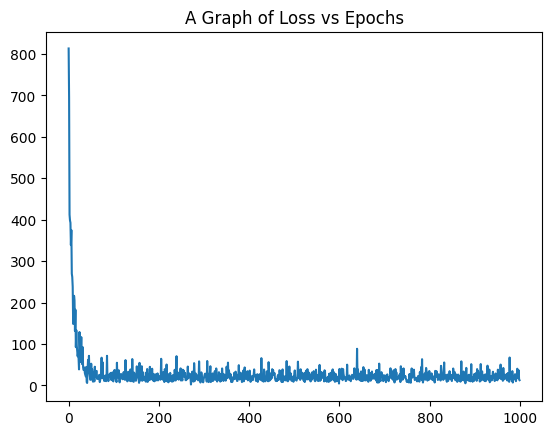

In [16]:
import matplotlib.pyplot as plt
plt.plot(list(range(1000)), train_result[0])
plt.title("A Graph of Loss vs Epochs")

In [17]:
def predict(x: ndarray, weights: ndarray) -> ndarray:
  # Predict house prices using the manually trained model
  N = np.dot(x, weights['W'])
  return np.add(N, weights['B'])

In [18]:
predictions = predict(x_test, weights)
print(np.round(predictions, 4))

[[40.2463]
 [16.4142]
 [19.32  ]
 [ 3.4998]
 [23.028 ]
 [22.3762]
 [17.8165]
 [23.6943]
 [31.2979]
 [ 9.1894]
 [32.0281]
 [18.0311]
 [16.5453]
 [35.7831]
 [17.6947]
 [24.8802]
 [17.9992]
 [25.6285]
 [26.3064]
 [25.8813]
 [20.9966]
 [22.4608]
 [14.0104]
 [24.6758]
 [14.2799]
 [27.5267]
 [28.7945]
 [35.6307]
 [35.1554]
 [19.8768]
 [ 6.1615]
 [12.2335]
 [27.6693]
 [21.2173]
 [21.5786]
 [38.8683]
 [35.5818]
 [24.6258]
 [27.1795]
 [27.9953]
 [36.391 ]
 [23.8475]
 [34.0195]
 [17.9324]
 [29.0451]
 [30.3516]
 [21.2829]
 [20.0894]
 [ 4.4035]
 [24.1532]
 [20.3353]
 [13.1044]
 [22.4377]
 [25.0213]
 [26.2101]
 [35.8276]
 [24.6136]
 [23.9461]
 [20.6606]
 [20.6315]
 [23.1733]
 [32.7499]
 [14.7888]
 [32.6803]
 [20.5827]
 [32.1578]
 [30.3532]
 [16.5731]
 [14.6238]
 [14.9169]
 [14.7782]
 [18.6228]
 [13.8147]
 [13.1013]
 [16.7908]
 [20.3444]
 [ 8.8332]
 [18.7848]
 [23.4236]
 [20.9829]
 [19.5777]
 [24.4578]
 [24.2386]
 [20.2421]
 [23.8381]
 [-5.1583]
 [26.9204]
 [16.4298]
 [21.1114]
 [ 6.387 ]
 [22.225 ]

In [19]:
print("MSE::", mse(y_test, predictions))
print("MAE::", mae(y_test, predictions))
print("RMSE::", rmse(y_test, predictions))

MSE:: 25.49414579207268
MAE:: 3.562798207878765
RMSE:: 5.049172782948974


In [20]:
np.mean(np.round(y_test, 4))
np.multiply(np.round(np.divide(rmse(y_test, predictions), np.mean(y_test)), 4), 100)

np.float64(22.869999999999997)

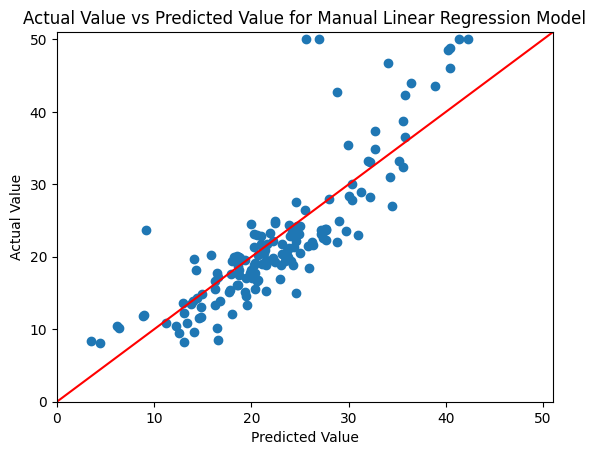

In [21]:
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Actual Value vs Predicted Value for Manual Linear Regression Model")
plt.xlim([0, 51])
plt.ylim([0, 51])
plt.scatter(predictions, y_test)
plt.plot([0,51], [0,51], color='red')
#plt.show()

Neual Network Regression

In [22]:
def sigmoid(x: ndarray) -> ndarray:
  return 1 / (1 + np.exp(-1.0 * x))

In [23]:
test_matrix = np.arange(-5,5,0.01)
sigmoid_matrix = sigmoid(test_matrix)
print(sigmoid_matrix)
print(test_matrix)

[0.0067 0.0068 0.0068 0.0069 0.007  0.007  0.0071 0.0072 0.0072 0.0073
 0.0074 0.0075 0.0075 0.0076 0.0077 0.0078 0.0078 0.0079 0.008  0.0081
 0.0082 0.0082 0.0083 0.0084 0.0085 0.0086 0.0087 0.0087 0.0088 0.0089
 0.009  0.0091 0.0092 0.0093 0.0094 0.0095 0.0096 0.0097 0.0098 0.0099
 0.01   0.0101 0.0102 0.0103 0.0104 0.0105 0.0106 0.0107 0.0108 0.0109
 0.011  0.0111 0.0112 0.0113 0.0114 0.0115 0.0117 0.0118 0.0119 0.012
 0.0121 0.0122 0.0124 0.0125 0.0126 0.0127 0.0129 0.013  0.0131 0.0133
 0.0134 0.0135 0.0137 0.0138 0.0139 0.0141 0.0142 0.0143 0.0145 0.0146
 0.0148 0.0149 0.0151 0.0152 0.0154 0.0155 0.0157 0.0158 0.016  0.0161
 0.0163 0.0165 0.0166 0.0168 0.017  0.0171 0.0173 0.0175 0.0176 0.0178
 0.018  0.0182 0.0183 0.0185 0.0187 0.0189 0.0191 0.0193 0.0195 0.0196
 0.0198 0.02   0.0202 0.0204 0.0206 0.0208 0.021  0.0212 0.0215 0.0217
 0.0219 0.0221 0.0223 0.0225 0.0228 0.023  0.0232 0.0234 0.0237 0.0239
 0.0241 0.0244 0.0246 0.0248 0.0251 0.0253 0.0256 0.0258 0.0261 0.0263
 0.0266

Text(0, 0.5, 'sigmoid(x)')

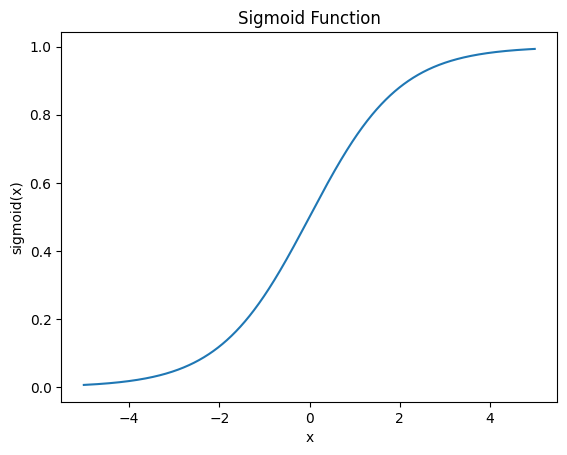

In [25]:
plt.plot(test_matrix, sigmoid_matrix)
plt.title("Sigmoid Function")
plt.ylim()
plt.xlabel("x")
plt.ylabel("sigmoid(x)")

In [ ]:
def nn_init_weights(input_size: int,
                    hidden_size: int) -> Dict[str, ndarray]:
    # Initialize wieghts for a forward pass for a step-by-step neural network
    weights: Dict[str, ndarray] = {}
    weights['W1'] = np.random.randn(input_size, hidden_size)
    weights['B1'] = np.random.randn(1, hidden_size)
    weights['W2'] = np.random.randn(hidden_size, 1)
    weights['B2'] = np.random.randn(1,1)
    return weights



In [26]:
def nn_forward_pass(x: ndarray,
                    y: ndarray,
                    weights: Dict[str, ndarray]) -> Tuple[Dict[str, ndarray], float]:
    # Assert that no observation is missing
    assert x.shape[0] == y.shape[0]
    M1 = np.dot(x, weights['W1'])
    N1 = np.add(M1, weights['B1'])
    O1 = sigmoid(N1)

    M2 = np.dot(O1, weights['W2'])
    P = np.add(M2, weights['B2'])
    loss = np.mean(np.square(y-P))

    forward_pass_result: Dict[str, ndarray] = {}
    forward_pass_result['Y'] = y
    forward_pass_result['M1'] = M1
    forward_pass_result['N1'] = N1
    forward_pass_result['O1'] = O1
    forward_pass_result['M2'] = M2
    forward_pass_result['P'] = P

    return forward_pass_result, loss

In [27]:
def nn_loss_gradient(x: ndarray,
                     weights: Dict[str, ndarray],
                     forward_pass_result: Tuple[Dict[str, ndarray]]) -> Dict[str, ndarray]:
    # Computations of the partial derivative of the each output with respect to the input
    dLdP = -(forward_pass_result['Y'] - forward_pass_result['P'])
    dPdM2 = np.ones_like(forward_pass_result['M2'])
    dLdM2 = dLdP * dPdM2
    dPdB2 = np.ones_like(weights['B2'])
    dLdB2 = (dLdP * dPdB2).sum(axis=0)
    dM2dW2 = np.transpose(forward_pass_result['O1'], (1,0))
    dLdW2 = np.dot(dM2dW2, dLdP)
    dM2dO1 = np.transpose(forward_pass_result['W2'], (1,0))
    dLdO1 = np.dot(dLdM2, dM2dO1)
    dO1dN1 = sigmoid((forward_pass_result['N1']) * (1- sigmoid(forward_pass_result['N1'])))
    dLdN1 = np.dot(dLdO1, dO1dN1)
    dN1dB1 = np.ones_like(weights['B1'])
    dN1dM1 = np.ones_like(forward_pass_result['M1'])
    dLdB1 = (dLdN1 * dN1dB1).sum(axis=0)
    dLdM1 = np.dot(dLdN1, dN1dM1)
    dM1dW1 = np.transpose(forward_pass_result['X'], (1,0))
    dLdW1 = np.dot(dLdM1, dM1dW1)

    loss_gradient: Dict[str, ndarray] = {}
    loss_gradient['W2'] = dLdW2
    loss_gradient['B2'] = dLdB2.sum(axis=0)
    loss_gradient['W1'] = dLdW1
    loss_gradient['B1'] = dLdB1.sum(axis=0)

    return loss_gradient